In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF, NeuMF
import pandas as pd
import numpy as np
import random
# import matha
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/yelp/indexed_interactions.csv",
    sep="\t",
    header=0,
    names=[ "itemID","Category", "userID","Rating", "Gender"],
)
rating_data = rating_data_pd[["userID", "itemID","Rating"]].to_numpy()
rating_data.__len__()
rating_data_pd


,itemID,Category,userID,Rating,Gender
0,0,Food & Restaurants|Drinks & Spirits,0,5,F
1,0,Food & Restaurants|Drinks & Spirits,1,4,F
2,0,Food & Restaurants|Drinks & Spirits,2,5,F
3,0,Food & Restaurants|Drinks & Spirits,3,3,M
4,0,Food & Restaurants|Drinks & Spirits,4,3,F
...,...,...,...,...,...
97986,1271,Food & Restaurants,1060,3,F
97987,1271,Food & Restaurants,161,2,M
97988,1271,Food & Restaurants,25,3,F
97989,1271,Food & Restaurants,280,4,F


In [3]:

restaurants = pd.read_csv("./cornac/data_c/yelp/i_id_mapping.csv",sep="\t",
    header=0,
    names=[ "item_id","Category","itemID"])
restaurants=restaurants.sort_values(by="itemID")

unique_categories = [
    "Active Life & Fitness",
    "Arts & Entertainment",
    "Automotive",
    "Bars & Nightlife",
    "Coffee,Tea & Desserts",
    "Drinks & Spirits",
    "Education & Learning",
    "Event Services",
    "Family & Kids",
    "Food & Restaurants",
    "Health & Beauty",
    "Home & Garden",
    "Miscellaneous",
    "Outdoor Activities",
    "Public Services & Community",
    "Shopping & Fashion",
    "Specialty Food & Groceries",
    "Sports & Recreation",
    "Technology & Electronics",
    "Travel & Transportation",
    "Asian",
]
for c in unique_categories:
    restaurants[c] = 0
for index, row in restaurants.iterrows():
    cats = row["Category"].split("|")
    for cat in cats:
        restaurants.at[index, cat] = 1

cat = restaurants[unique_categories]
# cat[:1]
item_features_numpy = cat.to_numpy()
item_features = {
    str(item_id): {"category_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
# ids = list(range(0, 3416))

In [4]:
restaurants

,item_id,Category,itemID,Active Life & Fitness,Arts & Entertainment,Automotive,Bars & Nightlife,"Coffee,Tea & Desserts",Drinks & Spirits,Education & Learning,...,Home & Garden,Miscellaneous,Outdoor Activities,Public Services & Community,Shopping & Fashion,Specialty Food & Groceries,Sports & Recreation,Technology & Electronics,Travel & Transportation,Asian
0,34,Food & Restaurants|Drinks & Spirits,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,250,Food & Restaurants|Drinks & Spirits,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,759,Asian|Food & Restaurants,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1085,Food & Restaurants,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1122,Travel & Transportation,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267,188255,Food & Restaurants,1267,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1268,188310,Food & Restaurants,1268,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1269,188449,Food & Restaurants|Bars & Nightlife,1269,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1270,188454,Food & Restaurants,1270,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:

users = pd.read_csv("./cornac/data_c/yelp/u_id_mapping.csv", sep="\t",header=0,
    names=[ "user_id","Gender","userID"])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
users = users.sort_values(by="userID")
users = users[["Gender", "userID"]]

user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
# print(item_features_numpy.shape)

(1316, 2)


In [6]:
# users
user_features_numpy[:,1]

array([   0,    1,    2, ..., 1313, 1314, 1315])

In [7]:
dataset = rating_data
unique_categories.__len__()

21

In [ ]:
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,fmt="UIR"
)
models = []
x=[]
alpha_values = [0,0.1,0.2, 0.3, 0.4, 0.5, 0.6 ]
# alpha_values = [0]
for i in range(len(alpha_values)):
    # learning
    models.append(
        NeuMF(num_factors=16, layers=[32,16], act_fn="relu", num_epochs=50, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=alpha_values[i], top_k=50, name=str(alpha_values[i])+ "neumf")

    )
    # model = NeuMF(num_factors=64, layers=[128,64], act_fn="relu", num_epochs=100, batch_size=1024, num_neg=3, backend="pytorch", lr=0.001, alp=alpha_values[i], top_k=50, name=str(alpha_values[i])+ "neumf")
    # model = NeuMF(num_factors=32, layers=[64,32], act_fn="relu", num_epochs=64, batch_size=256, num_neg=3, backend="pytorch", lr=0.001, alp=alpha_values[i], top_k=50, name=str(alpha_values[i])+ "neumf")

# Early stopping:
# - best epoch = 5, stopped epoch = 15
# - best monitored value = 0.062177 (delta = 0.000021)
 

cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([   0,    0,    0, ..., 1315, 1315, 1315]), array([   0,    1,    2, ..., 1030,  793, 1250]), array([4., 5., 2., ..., 4., 5., 5.]))
Number of users = 1316
Number of items = 1272
Number of ratings = 67470
Max rating = 5.0
Min rating = 1.0
Global mean = 3.9
Global mean Imolicit= 1.0
::::::::
OrderedDict([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (55, 55), (56, 56), (57, 57), (58, 58), (59, 5

100%|██████████| 50/50 [00:57<00:00,  1.16s/it, loss=0.343]


[0.7208667993545532, 0.7204797267913818, 0.7200902104377747, 0.7196975946426392, 0.7193032503128052, 0.7189062833786011, 0.7184975743293762, 0.7180882692337036, 0.7176730036735535, 0.717251181602478, 0.716827929019928, 0.7163775563240051, 0.7159660458564758, 0.7155175805091858, 0.7150483727455139, 0.7145943641662598, 0.7141289114952087, 0.7136720418930054, 0.7131878137588501, 0.712665319442749, 0.7121648788452148, 0.7116670608520508, 0.7111510634422302, 0.7106367349624634, 0.7101036906242371, 0.7095569372177124, 0.7089728713035583, 0.7083853483200073, 0.7078842520713806, 0.7072397470474243, 0.7066293954849243, 0.7059954404830933, 0.7053066492080688, 0.7046659588813782, 0.7039289474487305, 0.7033870220184326, 0.7027018070220947, 0.7019182443618774, 0.7012882828712463, 0.7004278898239136, 0.6997677683830261, 0.6989838480949402, 0.6980836391448975, 0.6973662972450256, 0.6964836716651917, 0.6957172751426697, 0.6947833299636841, 0.693936824798584, 0.6931129693984985, 0.6921788454055786, 0.6

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 2022.62it/s]



[0.1neumf] Training started!


...

100%|██████████| 50/50 [24:41<00:00, 29.64s/it, loss=0.543] 


[0.5499207973480225, 0.5498284697532654, 0.5497568249702454, 0.5496220588684082, 0.5495367050170898, 0.5494626760482788, 0.5494143962860107, 0.5493308901786804, 0.5491893291473389, 0.5491912364959717, 0.5490657091140747, 0.5489957928657532, 0.5488893985748291, 0.5488383769989014, 0.5487244725227356, 0.5486613512039185, 0.5486107468605042, 0.5485249757766724, 0.5484495759010315, 0.5483399033546448, 0.5483172535896301, 0.5482413172721863, 0.5481176972389221, 0.5480616092681885, 0.5480766892433167, 0.5479432344436646, 0.5478944778442383, 0.5478299856185913, 0.547786295413971, 0.5477023124694824, 0.547611653804779, 0.5475330352783203, 0.5474438667297363, 0.5473895072937012, 0.5473823547363281, 0.5472954511642456, 0.5472731590270996, 0.547149121761322, 0.5472774505615234, 0.5471130609512329, 0.5470364093780518, 0.5469669103622437, 0.5468561053276062, 0.5468893647193909, 0.5467037558555603, 0.5466868877410889, 0.5466497540473938, 0.546479344367981, 0.5465402007102966, 0.5464501976966858, 0.5

Ranking: 100%|██████████| 1316/1316 [00:00<00:00, 1943.10it/s]



[0.5neumf] Training started!


 86%|████████▌ | 43/50 [12:19<03:10, 27.28s/it, loss=0.516]

In [27]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
print(len(user_ids))
print(len(item_ids))
print(user_ids)
print(item_ids)

1316
1272
[   0    1    2 ... 1313 1314 1315]
[0 1 2 ... 1269 1270 1271]


In [28]:
# models[0].save("./saved")
import pickle

with open('mf100kyelp.pkl', 'wb') as f:
    # Pickle the 'data' dictionary using the highest protocol available.
    pickle.dump(models, f, pickle.HIGHEST_PROTOCOL)


In [29]:
user_ids = users.to_numpy()[:, 1]
item_ids = restaurants.to_numpy()[:, 2]
item_ids.__len__()
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [30]:
np.save("reco_matrix_mf_yelp_100k.npy", reco_matrix)
# np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
# np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all_mf_yelp_100k.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [31]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision


top_k = 50
###intialize them
gp = GenrePrecision(users, unique_categories, top_k)

In [32]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], restaurants))


restaurants = restaurants.rename(columns={"Category": "genres"})
# ####IR Metrics####
# ####Rprecision####
model_grps = []
# for i in range(len(models)):
#     model_grps.append(grp.compute(reco_matrix_top_r[i], restaurants_df, restaurants))


In [33]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


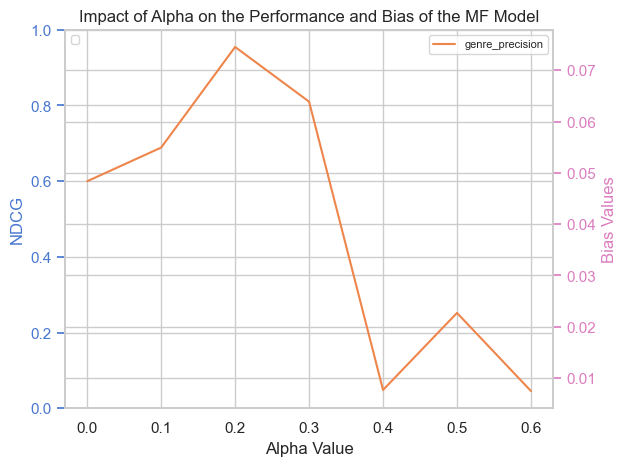

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]

x = alpha_values
upper_bound = 7

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()
#
# ax1.plot(x, ndcg_list, linestyle="--", color=pastel_palette[0], label="NDCG")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("NDCG", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x, gp_sum, label=titles[0], color=pastel_palette[1])
# ax2.plot(x, gm_sum, label=titles[2], color=pastel_palette[3])
# ax2.plot(x, gdcg_sum, label=titles[3], color=pastel_palette[4])
# ax2.plot(x, gmrr_sum, label=titles[4], color=pastel_palette[5])
# ax2.plot(x, grp_sum, label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1) 
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.show()
#  VAECF(
#             k=20,
#             autoencoder_structure=[64,32],
#             act_fn="relu",
#             likelihood="bern",
#             n_epochs=50,
#             batch_size=128,
#             learning_rate=0.0005,
#             alpha=alpha_values[i],
#             top_k=50,
#             beta=1,
#             name=f"a={alpha_values[i]} vae",
#             seed=123,
#             verbose=True,
#             # early_stopping=True
#         )
 
 NeuMF(num_factors=8, 
       layers=[32,16,8], act_fn="relu",
       num_epochs=50, batch_size=256, 
       num_neg=3, backend="pytorch", 
       lr=0.001, alp=alpha_values[i], top_k=50, 
       name=str(alpha_values[i])+ "neumf")

  